In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA # Para poder graficar texto en 2D
import kagglehub
import os

# 1. Descargar dataset
path = kagglehub.dataset_download("nikitamanaenkov/protein-benchmark-dataset")
file_path = os.path.join(path, "random_100_organisms.csv")
df = pd.read_csv(file_path)

# 2. Creamos una columna de texto combinado (Embeddings de texto con TF-IDF)
# Combinamos nombre latino y familia para encontrar parentescos
df['text_features'] = df['latin'] + " " + df['family'] + " " + df['common_name']

print("Ejemplo de texto a procesar:", df['text_features'].iloc[0])
X = df['text_features']

c:\Users\tteru\.pyenv\pyenv-win\versions\3.12.8\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 42.7k/42.7k [00:00<00:00, 605kB/s]

Extracting files...
Ejemplo de texto a procesar: Dacrymyces chrysocomus (Bull.) Tul. Dacrymycetaceae Dacrymyces chrysocomus


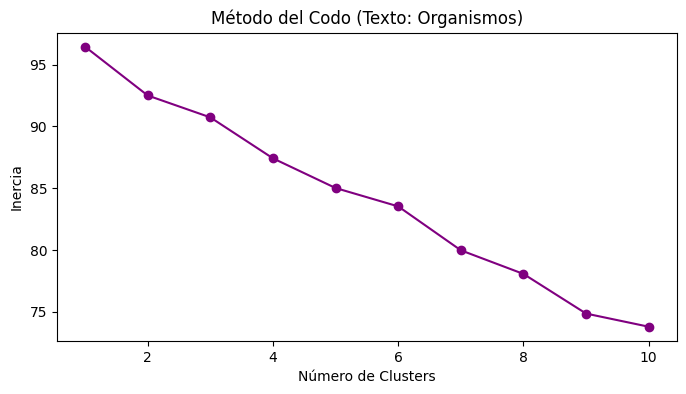

In [2]:
# Vectorizamos el texto temporalmente para el método del codo
tfidf_temp = TfidfVectorizer()
X_tfidf_temp = tfidf_temp.fit_transform(X)

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init="auto")
    km.fit(X_tfidf_temp)
    wcss.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(range(1, 11), wcss, marker='o', color='purple')
plt.title('Método del Codo (Texto: Organismos)')
plt.xlabel('Número de Clusters')
plt.ylabel('Inercia')
plt.show()

In [3]:
from sklearn.model_selection import train_test_split

# División 80/20
X_train, X_test = train_test_split(X, test_size=0.20, random_state=42)

# Pipeline: Vectorizador TF-IDF + KMeans
# Usaremos k=5 ya que el dataset menciona 5 reinos (kingdoms) principales
pipe = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(stop_words='english')),
    ("kmeans", KMeans(n_clusters=5, random_state=42, n_init="auto"))
])

# Entrenamiento
pipe.fit(X_train)

# Predicción en el set de prueba
test_clusters = pipe.predict(X_test)

df_test = pd.DataFrame({'texto': X_test, 'cluster': test_clusters})
print("Clasificación de organismos en Test:")
print(df_test.head())

Clasificación de organismos en Test:
                                                texto  cluster
83  Hyperthermus butylicus Zillig et al., 1991 Pyr...        4
53  Filinia opoliensis (Zacharias, 1898) Trochosph...        2
70  Deinococcus navajonensis Rainey & da Costa, 20...        0
45  Characium heteromorphum Reinsch Characiaceae C...        4
44  Hexarthra polyodonta (Hauer, 1957) Hexarthrida...        1


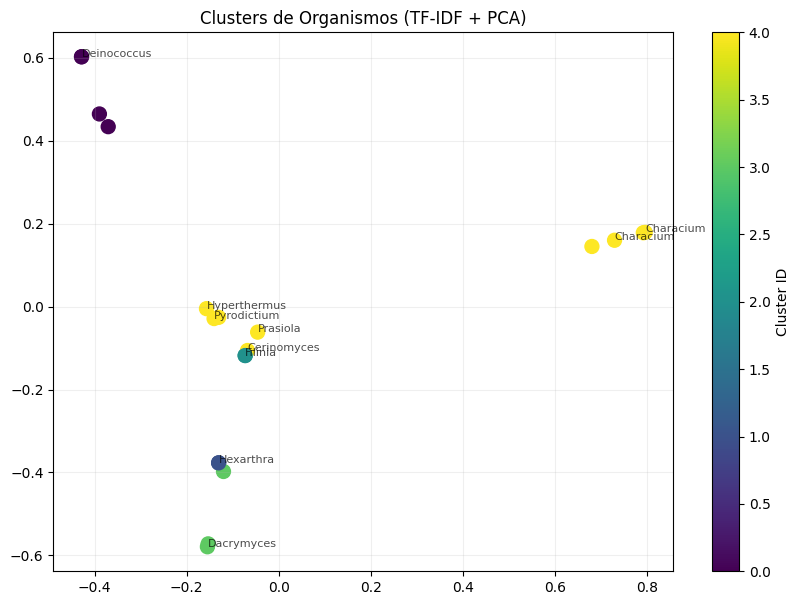

In [8]:
# Para graficar texto, necesitamos reducir las dimensiones a 2 (ejes X e Y)
tfidf_matrix = pipe.named_steps["tfidf"].transform(X_test).toarray()
pca = PCA(n_components=2)
X_2d = pca.fit_transform(tfidf_matrix)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=test_clusters, cmap='viridis', s=100)

# Añadimos etiquetas para saber qué organismo es cada punto (solo algunos)
for i, txt in enumerate(X_test.iloc[:10]):
    plt.annotate(txt.split()[0], (X_2d[i, 0], X_2d[i, 1]), fontsize=8, alpha=0.7)

plt.title("Clusters de Organismos (TF-IDF + PCA)")
plt.colorbar(scatter, label='Cluster ID')
plt.grid(True, alpha=0.2)
plt.show()

In [9]:
# Prueba con un organismo nuevo
nuevo_ejemplo = ["Sea urchin Strongylocentrotus purpuratus Animalia Strongylocentrotidae"]
cluster_predicho = pipe.predict(nuevo_ejemplo)

print(f"El nuevo organismo se ha clasificado en el Cluster: {cluster_predicho[0]}")

El nuevo organismo se ha clasificado en el Cluster: 4
